In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

In [2]:
class Standard_CNN(nn.Module):
    def __init__(self):#modified vgg16+lenet5
        super().__init__()
        self.Conv1 = nn.Conv2d(1,6,kernel_size=3,stride=1,padding=1)#maxpooling doesnt change the cin or cout.. only downsample the picture
        self.Conv2 = nn.Conv2d(6,16,kernel_size=3,stride=1,padding=1)
        self.fc1    = nn.Linear(16*4*4,120)
        self.fc2    = nn.Linear(120,84)
        self.fc3    = nn.Linear(84,10)
    def forward(self,x):
        x = torch.relu(self.Conv1(x))
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = torch.relu(self.Conv2(x))
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = x.view(-1,16*4*4)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [3]:
transform = transforms.Compose(
    [transforms.Pad(padding=2),transforms.ToTensor()] #make the 28x28 fashionmnist picture 32x32
)

In [4]:
batch_size = 50
data_root = "../FashionMNIST"
trainset = torchvision.datasets.FashionMNIST(root=data_root,train=True,download=True,transform=transform)
testset = torchvision.datasets.FashionMNIST(root=data_root,train=False,download=True,transform=transform)
trainloader = torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True)
testloader = torch.utils.data.DataLoader(testset,batch_size=batch_size, shuffle=False)
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")
model = Standard_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(model.parameters(),lr=0.001)
optimizer2 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0)
optimizer3 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)


Using device: mps


In [5]:
def accuracy(loader):
    model.eval()
    correct, total = 0,0
    with torch.no_grad(): # not train on evaluation
        for data,labels in loader:
            data, labels = data.to(device), labels.to(device)
            output = model(data)
            _,predicted = torch.max(output.data,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct /total

In [6]:
epochs = 20
adam_batch_losses = []
adam_train_losses = []
adam_train_accuracies = []
adam_test_accuracies = []
adam_start = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model(images)
        loss = criterion(output, label)
        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    adam_train_losses.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    adam_train_accuracies.append(train_acc)
    adam_test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
adam_end = time.time()
adam_time = adam_end - adam_start
print("time for training", adam_time, "seconds")

Epoch 1/20 | Loss: 0.7022 | Train Acc: 82.88% | Test Acc: 82.00%
Epoch 2/20 | Loss: 0.4405 | Train Acc: 85.79% | Test Acc: 85.24%
Epoch 3/20 | Loss: 0.3734 | Train Acc: 87.83% | Test Acc: 87.10%
Epoch 4/20 | Loss: 0.3389 | Train Acc: 88.14% | Test Acc: 87.10%
Epoch 5/20 | Loss: 0.3169 | Train Acc: 89.01% | Test Acc: 87.81%
Epoch 6/20 | Loss: 0.2972 | Train Acc: 89.03% | Test Acc: 88.23%
Epoch 7/20 | Loss: 0.2856 | Train Acc: 89.87% | Test Acc: 88.67%
Epoch 8/20 | Loss: 0.2756 | Train Acc: 90.43% | Test Acc: 89.08%
Epoch 9/20 | Loss: 0.2658 | Train Acc: 90.29% | Test Acc: 88.80%
Epoch 10/20 | Loss: 0.2574 | Train Acc: 90.44% | Test Acc: 89.06%
Epoch 11/20 | Loss: 0.2466 | Train Acc: 90.86% | Test Acc: 89.03%
Epoch 12/20 | Loss: 0.2422 | Train Acc: 91.34% | Test Acc: 89.44%
Epoch 13/20 | Loss: 0.2355 | Train Acc: 91.35% | Test Acc: 89.72%
Epoch 14/20 | Loss: 0.2290 | Train Acc: 91.89% | Test Acc: 89.97%
Epoch 15/20 | Loss: 0.2248 | Train Acc: 91.83% | Test Acc: 89.93%
Epoch 16/20 | Loss:

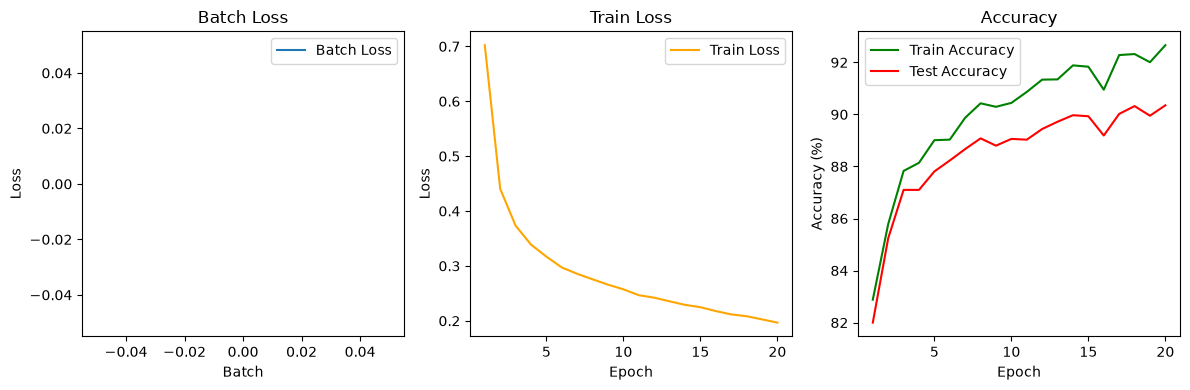

In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(adam_batch_losses, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), adam_train_losses, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), adam_train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), adam_test_accuracies, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
epochs = 20
sgd_batch_losses = []
sgd_train_losses = []
sgd_train_accuracies = []
sgd_test_accuracies = []
sgd_start = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model(images)
        loss = criterion(output, label)
        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    sgd_train_losses.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    sgd_train_accuracies.append(train_acc)
    sgd_test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
sgd_end = time.time()
sgd_time = sgd_end - sgd_start
print("time for training", sgd_time, "seconds")

Epoch 1/10 | Loss: 0.1727 | Train Acc: 93.58% | Test Acc: 90.90%
Epoch 2/10 | Loss: 0.1675 | Train Acc: 93.78% | Test Acc: 91.12%
Epoch 3/10 | Loss: 0.1655 | Train Acc: 93.84% | Test Acc: 91.07%
Epoch 4/10 | Loss: 0.1644 | Train Acc: 93.88% | Test Acc: 91.05%
Epoch 5/10 | Loss: 0.1635 | Train Acc: 93.90% | Test Acc: 91.17%
Epoch 6/10 | Loss: 0.1628 | Train Acc: 93.94% | Test Acc: 91.24%
Epoch 7/10 | Loss: 0.1622 | Train Acc: 93.96% | Test Acc: 91.27%
Epoch 8/10 | Loss: 0.1617 | Train Acc: 93.99% | Test Acc: 91.25%
Epoch 9/10 | Loss: 0.1613 | Train Acc: 93.99% | Test Acc: 91.29%
Epoch 10/10 | Loss: 0.1609 | Train Acc: 93.94% | Test Acc: 91.26%
time for training 176.46198105812073 seconds


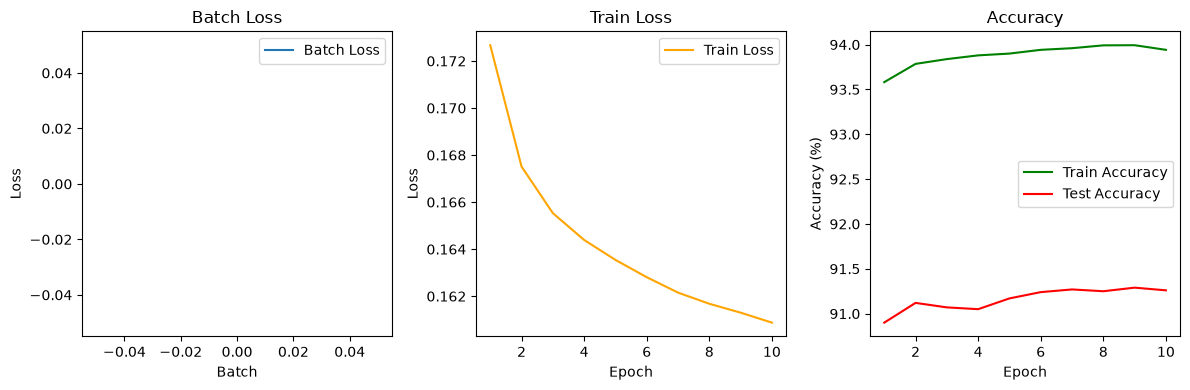

In [9]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(sgd_batch_losses, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), sgd_train_losses, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), sgd_train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), sgd_test_accuracies, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
epochs = 20
sgd_m_batch_losses = []
sgd_m_train_losses = []
sgd_m_train_accuracies = []
sgd_m_test_accuracies = []
sgd_m_start = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model(images)
        loss = criterion(output, label)
        optimizer3.zero_grad()
        loss.backward()
        optimizer3.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    sgd_m_train_losses.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    sgd_m_train_accuracies.append(train_acc)
    sgd_m_test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
sgd_m_end = time.time()
sgd_m_time = sgd_m_end - sgd_m_start
print("time for training", sgd_m_time, "seconds")

Epoch 1/10 | Loss: 0.1659 | Train Acc: 93.85% | Test Acc: 91.17%
Epoch 2/10 | Loss: 0.1653 | Train Acc: 94.06% | Test Acc: 91.22%
Epoch 3/10 | Loss: 0.1634 | Train Acc: 93.14% | Test Acc: 90.27%
Epoch 4/10 | Loss: 0.1615 | Train Acc: 94.02% | Test Acc: 91.22%
Epoch 5/10 | Loss: 0.1616 | Train Acc: 94.12% | Test Acc: 91.03%
Epoch 6/10 | Loss: 0.1598 | Train Acc: 94.03% | Test Acc: 90.99%
Epoch 7/10 | Loss: 0.1588 | Train Acc: 94.11% | Test Acc: 91.10%
Epoch 8/10 | Loss: 0.1575 | Train Acc: 94.18% | Test Acc: 91.12%
Epoch 9/10 | Loss: 0.1577 | Train Acc: 94.14% | Test Acc: 91.23%
Epoch 10/10 | Loss: 0.1569 | Train Acc: 94.39% | Test Acc: 91.13%
time for training 179.18721890449524 seconds


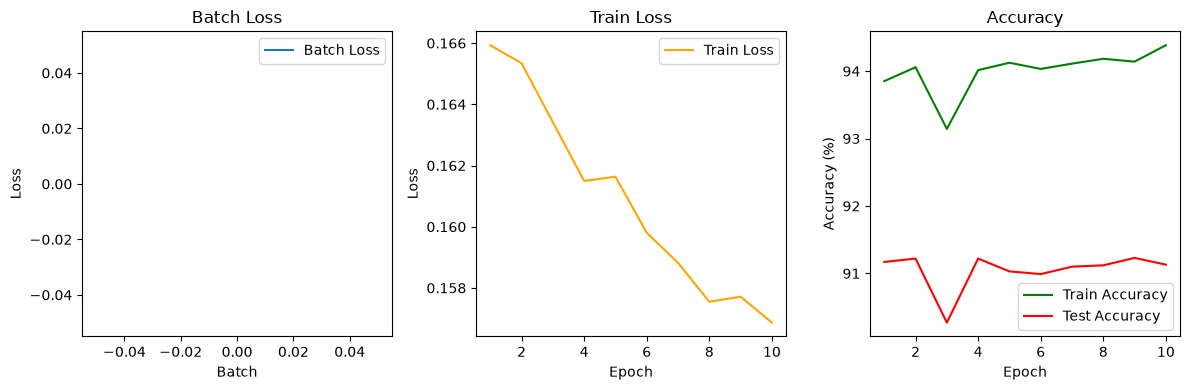

In [11]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(sgd_m_batch_losses, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), sgd_m_train_losses, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), sgd_m_train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), sgd_m_test_accuracies, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
class DepthWise_Separable_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1_depth = nn.Conv2d(1,1,kernel_size=3,padding=1,groups=1)
        self.batch_norm_1_1 = nn.BatchNorm2d(1)
        self.conv1_point = nn.Conv2d(1,6,kernel_size=1,groups=1)
        self.batch_norm_1_2 = nn.BatchNorm2d(6)
        self.conv2_depth = nn.Conv2d(6,6,kernel_size=3,padding=1,groups=6)
        self.batch_norm_2_1 = nn.BatchNorm2d(6)
        self.conv2_point = nn.Conv2d(6,16,kernel_size=1,groups=1)
        self.batch_norm_2_2 = nn.BatchNorm2d(16)
        self.fc1    = nn.Linear(16*4*4,120)
        self.fc2    = nn.Linear(120,84)
        self.fc3    = nn.Linear(84,10)

    def forward(self,x):
        x = self.conv1_depth(x)
        x = self.batch_norm_1_1(x)
        x = torch.relu(x)
        x = self.conv1_point(x)
        x = self.batch_norm_1_2(x)
        x = torch.relu(x)
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = self.conv2_depth(x)
        x = self.batch_norm_2_1(x)
        x = torch.relu(x)
        x = self.conv2_point(x)
        x = self.batch_norm_2_2(x)
        x = torch.relu(x)
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = torch.max_pool2d(x,kernel_size=2,stride=2)
        x = x.view(-1,16*4*4)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [13]:
transform = transforms.Compose(
    [transforms.Pad(padding=2),transforms.ToTensor()] #make the 28x28 fashionmnist picture 32x32
)

In [14]:
batch_size = 50
data_root = "../FashionMNIST"
trainset = torchvision.datasets.FashionMNIST(root=data_root,train=True,download=True,transform=transform)
testset = torchvision.datasets.FashionMNIST(root=data_root,train=False,download=True,transform=transform)
trainloader = torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True)
testloader = torch.utils.data.DataLoader(testset,batch_size=batch_size, shuffle=False)
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")
model = DepthWise_Separable_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(model.parameters(),lr=0.001)
optimizer2 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0)
optimizer3 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

Using device: mps


In [15]:
def accuracy(loader):
    model.eval()
    correct, total = 0,0
    with torch.no_grad():
        for data,labels in loader:
            data, labels = data.to(device), labels.to(device)
            output = model(data)
            _,predicted = torch.max(output.data,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct /total

In [16]:
epochs = 20
adam_batch_losses_mobilenet = []
adam_train_losses_mobilenet = []
adam_train_accuracies_mobilenet = []
adam_test_accuracies_mobilenet = []
adam_start = time.time()
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model(images)
        loss = criterion(output, label)
        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    adam_train_losses_mobilenet.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    adam_train_accuracies_mobilenet.append(train_acc)
    adam_test_accuracies_mobilenet.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
adam_end = time.time()
adam_time = adam_end - adam_start
print("time for training", adam_time, "seconds")

Epoch 1/20 | Loss: 0.5712 | Train Acc: 84.24% | Test Acc: 83.24%
Epoch 2/20 | Loss: 0.4070 | Train Acc: 84.80% | Test Acc: 83.81%
Epoch 3/20 | Loss: 0.3631 | Train Acc: 86.41% | Test Acc: 85.24%
Epoch 4/20 | Loss: 0.3372 | Train Acc: 87.54% | Test Acc: 86.29%
Epoch 5/20 | Loss: 0.3218 | Train Acc: 88.78% | Test Acc: 87.18%
Epoch 6/20 | Loss: 0.3068 | Train Acc: 88.65% | Test Acc: 86.90%
Epoch 7/20 | Loss: 0.2950 | Train Acc: 89.28% | Test Acc: 87.58%
Epoch 8/20 | Loss: 0.2861 | Train Acc: 89.19% | Test Acc: 87.23%
Epoch 9/20 | Loss: 0.2786 | Train Acc: 89.99% | Test Acc: 87.91%
Epoch 10/20 | Loss: 0.2710 | Train Acc: 88.93% | Test Acc: 86.82%
Epoch 11/20 | Loss: 0.2641 | Train Acc: 90.61% | Test Acc: 87.83%
Epoch 12/20 | Loss: 0.2587 | Train Acc: 90.53% | Test Acc: 87.96%
Epoch 13/20 | Loss: 0.2520 | Train Acc: 90.67% | Test Acc: 87.96%
Epoch 14/20 | Loss: 0.2451 | Train Acc: 91.55% | Test Acc: 88.30%
Epoch 15/20 | Loss: 0.2409 | Train Acc: 91.60% | Test Acc: 88.36%
Epoch 16/20 | Loss:

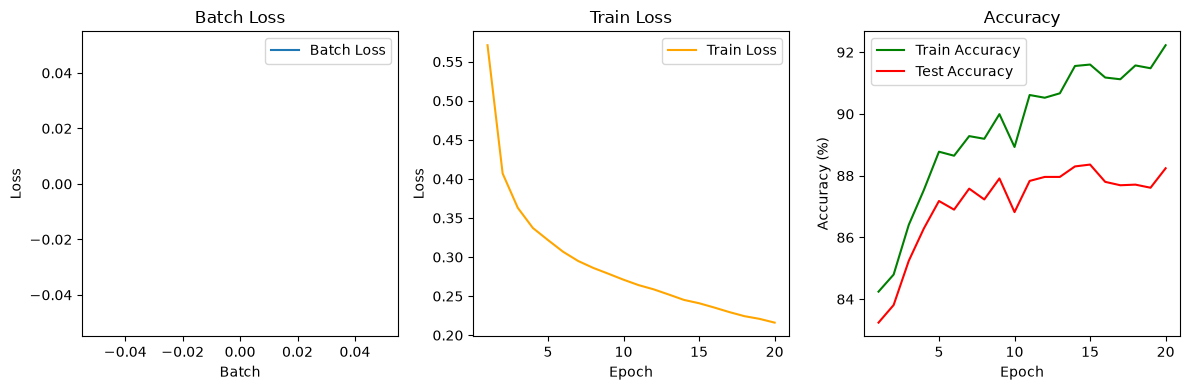

In [17]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(adam_batch_losses_mobilenet, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), adam_train_losses_mobilenet, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), adam_train_accuracies_mobilenet, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), adam_test_accuracies_mobilenet, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

SOTA models

In [18]:
from torchvision.models import MobileNet_V2_Weights

In [50]:
transform = transforms.Compose(
    [transforms.Resize(224),
     transforms.Grayscale(num_output_channels=3),
     transforms.ToTensor(),
     transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
     ] #make the 28x28 fashionmnist picture 32x32
)

In [51]:
model_pt = torchvision.models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
model_pt.classifier[1] = nn.Linear(model_pt.last_channel,10)

In [52]:
for param in model_pt.parameters():
    param.requires_grad = False
for param in model_pt.classifier[1].parameters():
    param.requires_grad = True

In [53]:
batch_size = 50
data_root = "../FashionMNIST"
trainset = torchvision.datasets.FashionMNIST(root=data_root,train=True,download=True,transform=transform)
testset = torchvision.datasets.FashionMNIST(root=data_root,train=False,download=True,transform=transform)
trainloader = torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True)
testloader = torch.utils.data.DataLoader(testset,batch_size=batch_size, shuffle=False)
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")
model_pt = model_pt.to(device)
criterion = nn.CrossEntropyLoss()
optimizer1 = torch.optim.Adam(filter(lambda p: p.requires_grad, model_pt.parameters()),lr=0.001)
#optimizer2 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0)
#optimizer3 = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

Using device: mps


In [54]:
def accuracy(loader):
    model_pt.eval()
    correct, total = 0,0
    with torch.no_grad(): # not train on evaluation
        for data,labels in loader:
            data, labels = data.to(device), labels.to(device)
            output = model_pt(data)
            _,predicted = torch.max(output.data,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct /total

In [ ]:
epochs = 20
mobilenetv2_batch_losses = []
mobilenetv2_train_losses = []
mobilenetv2_train_accuracies = []
mobilenetv2_test_accuracies = []
mobilenetv2_start = time.time()
for epoch in range(epochs):
    model_pt.train()
    model_pt.features.eval() #??
    running_loss = 0.0
    correct = 0
    total = 0
    for images,label in trainloader:
        images,label = images.to(device), label.to(device)
        output = model_pt(images)
        loss = criterion(output, label)
        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()
        running_loss += loss.item()
        _,predicted = torch.max(output,1)
        total += label.size(0)
        correct += (predicted == label).sum().item()
        
    avg_loss = running_loss / len(trainloader)
    adam_train_losses.append(avg_loss)
    
    # --- FIXED: Calculate accuracy per epoch inside the loop ---
    train_acc = accuracy(trainloader)
    test_acc = accuracy(testloader)
    mobilenetv2_train_accuracies.append(train_acc)
    mobilenetv2_test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")
mobilenetv2_end = time.time()
mobilenetv2_time = mobilenetv2_end - mobilenetv2_start
print("time for training", mobilenetv2_time, "seconds")

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(mobilenetv2_batch_losses, label='Batch Loss')
plt.title('Batch Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), mobilenetv2_train_losses, label='Train Loss', color='orange')
plt.title('Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), adam_train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, epochs + 1), adam_test_accuracies, label='Test Accuracy', color='red')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()